In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass

np.random.seed(1234)

stations = ["G", "L", "B", "Z"]

# Demand rates during peak periods [1000 passengers/h]
demand_peak = np.array(
    [
        [np.nan, 1.5, 2.2, 1.3],
        [np.nan, np.nan, 2.4, 1.1],
        [np.nan, np.nan, np.nan, 3.3],
        [np.nan, np.nan, np.nan, np.nan],
    ]
)

# Demand rates during off-peak periods [1000 passengers/h]
demand_offpeak = np.array(
    [
        [np.nan, 0.4, 0.3, 0.5],
        [np.nan, np.nan, 0.5, 0.3],
        [np.nan, np.nan, np.nan, 0.5],
        [np.nan, np.nan, np.nan, np.nan],
    ]
)

# Proportion of first class passengers during peak periods
first_class_ratio_peak = np.array(
    [
        [np.nan, 0.13, 0.15, 0.17],
        [np.nan, np.nan, 0.21, 0.18],
        [np.nan, np.nan, np.nan, 0.32],
        [np.nan, np.nan, np.nan, np.nan],
    ]
)

# Proportion of first class passengers during off-peak periods
first_class_ratio_offpeak = np.array(
    [
        [np.nan, 0.21, 0.18, 0.23],
        [np.nan, np.nan, 0.24, 0.23],
        [np.nan, np.nan, np.nan, 0.19],
        [np.nan, np.nan, np.nan, np.nan],
    ]
)

df_demand_peak = pd.DataFrame(demand_peak, index=stations, columns=stations)
df_demand_offpeak = pd.DataFrame(demand_offpeak, index=stations, columns=stations)
df_first_class_ratio_peak = pd.DataFrame(
    first_class_ratio_peak, index=stations, columns=stations
)
df_first_class_ratio_offpeak = pd.DataFrame(
    first_class_ratio_offpeak, index=stations, columns=stations
)

In [28]:
def exponential_rng(lam=1.0):
    """Generates exponential random number."""
    if lam <= 0:
        return float("inf")
    return -np.log(np.random.rand()) / lam


# Price constants
PRICE_FIRST = 40
PRICE_SECOND = 20
MISSED_COST_FIRST = 30
MISSED_COST_SECOND = 10
EMPTY_COST_FIRST = 20
EMPTY_COST_SECOND = 10


def get_travel_time(station):
    """Returns the travel time to the next station in minutes"""
    if station == "G":
        return 40
    if station == "L":
        return 70
    if station == "B":
        return 60
    return 0


def get_num_stations(origin, destination):
    """Calculates the number of stations between origin and destination for tickets"""
    return stations.index(destination) - stations.index(origin)


def is_peak(time_minutes):
    """Checks if we are in peak hours (7-9 or 16-18)"""
    time_of_day = time_minutes % (24 * 60)
    # 7:00 = 420, 9:00 = 540, 16:00 = 960, 18:00 = 1080
    if (420 <= time_of_day <= 540) or (960 <= time_of_day <= 1080):
        return True
    return False

In [29]:
class Passenger:
    def __init__(self, arrival_time, origin, destination, is_first_class):
        self.arrival_time = arrival_time
        self.origin = origin
        self.destination = destination
        self.is_first_class = is_first_class
        self.missed_trains = 0


@dataclass
class TrainType:
    """Train can have a maximum number of six carriages"""

    name: str
    first_class_carriages: int
    second_class_carriages: int

    def __repr__(self):
        return f"{self.name}"


@dataclass
class Train:
    train_id: int
    # Standard composition: 1 first class (300) and 3 second class (1500)
    train_type: TrainType

    # Lists to keep track of passengers on board
    onboard_first: list = None
    onboard_second: list = None

    def __post_init__(self):
        self.onboard_first = []
        self.onboard_second = []

    @property
    def capacity_first(self):
        return self.train_type.first_class_carriages * 300

    @property
    def capacity_second(self):
        return self.train_type.second_class_carriages * 500

In [30]:
from dataclasses import dataclass


@dataclass
class Event:
    """Generic event."""

    time: float


class PassengerGeneration(Event):
    """A passenger arrives at the station"""

    def __init__(self, time, origin, destination, is_first_class):
        super().__init__(time)
        self.origin = origin
        self.destination = destination
        self.is_first_class = is_first_class


@dataclass
class TrainArrival(Event):
    """The train arrives at a station"""

    station: str
    train: Train


In [31]:
def get_arrival_rate(
    origin, destination, is_first_class, time
):  # Calculates the arrival rate (lambda) in passengers per minute for a specific route and class
    peak = is_peak(time)

    # Choose the correct dataframe based on time
    if peak:
        demand_df = df_demand_peak
        ratio_df = df_first_class_ratio_peak
    else:
        demand_df = df_demand_offpeak
        ratio_df = df_first_class_ratio_offpeak

    total_demand_per_hour = demand_df.loc[origin, destination] * 1000

    # If NaN, the route does not exist
    if pd.isna(total_demand_per_hour):
        return 0

    first_class_ratio = ratio_df.loc[origin, destination]

    if is_first_class:
        rate_per_hour = total_demand_per_hour * first_class_ratio
    else:
        rate_per_hour = total_demand_per_hour * (1 - first_class_ratio)

    # Return the rate per minute
    return rate_per_hour / 60.0


def generate_timetable(
    freq_peak, freq_offpeak
):  # Generates all train arrival events for the day
    train_events = []
    t = 0
    train_id = 0

    while t < 24 * 60:
        train = Train(train_id)
        current_time = t

        # Make the train travel through the stations
        for station in stations:
            train_events.append(TrainArrival(current_time, station, train))
            current_time += get_travel_time(station)

        if is_peak(t):
            t += freq_peak
        else:
            t += freq_offpeak

        train_id += 1

    return train_events

In [32]:
from dataclasses import dataclass


base_train = TrainType(name="base", first_class_carriages=1, second_class_carriages=3)
short_train = TrainType(name="short", first_class_carriages=1, second_class_carriages=1)
long_train = TrainType(name="long", first_class_carriages=2, second_class_carriages=5)


def t_in_intervals(t, intervals: list[tuple[float]] | None):
    """Checks if time t is within any of the given intervals"""
    return any(start <= t <= end for start, end in intervals or [])


@dataclass
class Scenario:
    train_frequency_peak: float
    train_frequency_offpeak: float
    train_config_1: TrainType
    train_config_2: TrainType | None = None
    train_config_3: TrainType | None = None  # maximum 3 types
    train_type_2_intervals: list[tuple[float]] = None
    train_type_3_intervals: list[tuple[float]] = None

    def get_timetable(
        self,
        sorted_by_time: bool = True,
    ) -> list[TrainArrival]:
        train_events = []
        t = 0
        train_id = 0

        while t < 24 * 60:
            train_type = self.train_config_1
            if t_in_intervals(t, self.train_type_2_intervals):
                train_type = self.train_config_2
            elif t_in_intervals(t, self.train_type_3_intervals):
                train_type = self.train_config_3

            train = Train(
                train_id=train_id,
                train_type=train_type,
            )
            current_time = t

            # Make the train travel through the stations
            for station in stations:
                train_events.append(TrainArrival(current_time, station, train))
                current_time += get_travel_time(station)

            if is_peak(t):
                t += self.train_frequency_peak
            else:
                t += self.train_frequency_offpeak

            train_id += 1
        if sorted_by_time:
            train_events.sort(key=lambda event: event.time)
        return train_events

    def __str__(self):
        return f"Peak frequency: {self.train_frequency_peak} min, Off-peak frequency: {self.train_frequency_offpeak} min"


@dataclass
class SimulationResult:
    time_history: list[int]
    queue_history: list[int]
    waiting_times: list[float]
    total_revenue: float
    total_missed_cost: float
    total_empty_cost: float
    list_available_first: list[int]
    list_available_second: list[int]
    times_available_first: list[float]
    times_available_second: list[float]

    def print_summary(self):
        print(f"Passengers served: {len(self.waiting_times):,.2f}")
        print(f"Average waiting time: {np.mean(self.waiting_times):.2f} minutes")
        print(f"Total revenue: {self.total_revenue:,.2f} CHF")
        print(f"Missed passenger costs: {self.total_missed_cost:,.2f} CHF")
        print(f"Empty seat costs: {self.total_empty_cost:,.2f} CHF")
        profit = self.total_revenue - self.total_missed_cost - self.total_empty_cost
        print(f"NET PROFIT: {profit:,.2f} CHF\n")

    def __repr__(self):
        return "Result"

In [33]:
example_scenario = Scenario(
    train_frequency_peak=5.0,
    train_frequency_offpeak=10.0,
    train_config_1=base_train,
    train_config_2=short_train,
    train_config_3=long_train,
    train_type_2_intervals=[(0, 1)],  # Short trains during peak hours
    train_type_3_intervals=[(1, 600)],  # Long trains during off-peak hours
)

for event in example_scenario.get_timetable()[:5]:
    print(event)

TrainArrival(time=0, station='G', train=Train(train_id=0, train_type=short, onboard_first=[], onboard_second=[]))
TrainArrival(time=10.0, station='G', train=Train(train_id=1, train_type=long, onboard_first=[], onboard_second=[]))
TrainArrival(time=20.0, station='G', train=Train(train_id=2, train_type=long, onboard_first=[], onboard_second=[]))
TrainArrival(time=30.0, station='G', train=Train(train_id=3, train_type=long, onboard_first=[], onboard_second=[]))
TrainArrival(time=40, station='L', train=Train(train_id=0, train_type=short, onboard_first=[], onboard_second=[]))


In [34]:
def simulate(scenario: Scenario) -> SimulationResult:

    # Initialize the queues at the stations
    queues = {}
    for s in stations:
        queues[s] = {"first": [], "second": []}

    events = scenario.get_timetable()

    # Generate the first passenger arrival event for each possible combination
    for origin in stations:
        for destination in stations:
            if stations.index(origin) >= stations.index(destination):
                continue

            for is_first in [True, False]:
                rate = get_arrival_rate(origin, destination, is_first, 0)
                if rate > 0:
                    time_first_arrival = exponential_rng(rate)
                    events.append(
                        PassengerGeneration(
                            time_first_arrival, origin, destination, is_first
                        )
                    )

    events.sort(key=lambda event: event.time)

    # State variables and statistics
    total_revenue = 0
    total_missed_cost = 0
    total_empty_cost = 0
    waiting_times = []

    # Lists to track queue over time for the plot
    time_history = []
    queue_history = []
    list_available_first = []
    list_available_second = []
    times_available_first = []
    times_available_second = []

    # Main loop
    while len(events) > 0:
        e = events.pop(0)

        if e.time > 24 * 60:
            break  # End of the day

        if isinstance(e, PassengerGeneration):
            # 1. Add the passenger to the platform queue
            p = Passenger(e.time, e.origin, e.destination, e.is_first_class)
            if p.is_first_class:
                queues[e.origin]["first"].append(p)
            else:
                queues[e.origin]["second"].append(p)

            # 2. Schedule the next generation
            rate = get_arrival_rate(e.origin, e.destination, e.is_first_class, e.time)
            next_time = e.time + exponential_rng(rate)
            events.append(
                PassengerGeneration(
                    next_time, e.origin, e.destination, e.is_first_class
                )
            )

        elif isinstance(e, TrainArrival):
            train = e.train
            station = e.station

            # 1. Passengers get off
            train.onboard_first = [
                p for p in train.onboard_first if p.destination != station
            ]
            train.onboard_second = [
                p for p in train.onboard_second if p.destination != station
            ]

            # 2. Passengers board
            if station != "Z":
                # First class boarding
                available_first = train.capacity_first - len(train.onboard_first)
                left_behind_first = []
                for p in queues[station]["first"]:
                    if available_first > 0:
                        train.onboard_first.append(p)
                        available_first -= 1
                        waiting_times.append(e.time - p.arrival_time)
                        total_revenue += PRICE_FIRST * get_num_stations(
                            p.origin, p.destination
                        )
                        total_missed_cost += p.missed_trains * MISSED_COST_FIRST
                    else:
                        p.missed_trains += 1
                        left_behind_first.append(p)
                queues[station]["first"] = left_behind_first
                total_empty_cost += available_first * EMPTY_COST_FIRST
                list_available_first.append(available_first)
                times_available_first.append(e.time)

                # Second class boarding
                available_second = train.capacity_second - len(train.onboard_second)
                left_behind_second = []
                for p in queues[station]["second"]:
                    if available_second > 0:
                        train.onboard_second.append(p)
                        available_second -= 1
                        waiting_times.append(e.time - p.arrival_time)
                        total_revenue += PRICE_SECOND * get_num_stations(
                            p.origin, p.destination
                        )
                        total_missed_cost += p.missed_trains * MISSED_COST_SECOND
                    else:
                        p.missed_trains += 1
                        left_behind_second.append(p)
                queues[station]["second"] = left_behind_second
                total_empty_cost += available_second * EMPTY_COST_SECOND
                list_available_second.append(available_second)
                times_available_second.append(e.time)

        # Calculate total passengers waiting right now
        current_total_queue = 0
        for s in stations:
            current_total_queue += len(queues[s]["first"]) + len(queues[s]["second"])

        time_history.append(e.time)
        queue_history.append(current_total_queue)

        events.sort(key=lambda event: event.time)

    return SimulationResult(
        time_history=time_history,
        queue_history=queue_history,
        waiting_times=waiting_times,
        total_revenue=total_revenue,
        total_missed_cost=total_missed_cost,
        total_empty_cost=total_empty_cost,
        list_available_first=list_available_first,
        list_available_second=list_available_second,
        times_available_first=times_available_first,
        times_available_second=times_available_second,
    )

In [35]:
print("Starting simulation")

# Scenario 1: Constant frequency every 20 minutes

scenarios = {
    "base scenario 1": {
        "scenario": Scenario(
            train_frequency_peak=20,
            train_frequency_offpeak=20,
            train_config_1=base_train,
        )
    },
    "base scenario 2": {
        "scenario": Scenario(
            train_frequency_peak=15,
            train_frequency_offpeak=30,
            train_config_1=base_train,
        )
    },
    "many trains": {
        "scenario": Scenario(
            train_frequency_peak=5, train_frequency_offpeak=5, train_config_1=base_train
        )
    },
    "few trains": {
        "scenario": Scenario(
            train_frequency_peak=30,
            train_frequency_offpeak=30,
            train_config_1=base_train,
        )
    },
    "long trains": {
        "scenario": Scenario(
            train_frequency_peak=20,
            train_frequency_offpeak=20,
            train_config_1=long_train,
        )
    },
}


for scenario_name, scenario in scenarios.items():
    print(f"Simulating {scenario_name}...")
    result = simulate(scenario["scenario"])
    scenario["result"] = result
    print("\n" + "=" * 50)
    print(f"SCENARIO: {scenario_name}")
    print("=" * 50)
    result.print_summary()

Starting simulation
Simulating base scenario 1...

SCENARIO: base scenario 1
Passengers served: 96,597.00
Average waiting time: 15.47 minutes
Total revenue: 3,664,760.00 CHF
Missed passenger costs: 472,990.00 CHF
Empty seat costs: 2,595,570.00 CHF
NET PROFIT: 596,200.00 CHF

Simulating base scenario 2...

SCENARIO: base scenario 2
Passengers served: 96,426.00
Average waiting time: 16.76 minutes
Total revenue: 3,658,460.00 CHF
Missed passenger costs: 554,570.00 CHF
Empty seat costs: 1,679,680.00 CHF
NET PROFIT: 1,424,210.00 CHF

Simulating many trains...

SCENARIO: many trains
Passengers served: 97,043.00
Average waiting time: 3.08 minutes
Total revenue: 3,662,760.00 CHF
Missed passenger costs: 0.00 CHF
Empty seat costs: 15,744,780.00 CHF
NET PROFIT: -12,082,020.00 CHF

Simulating few trains...

SCENARIO: few trains
Passengers served: 96,133.00
Average waiting time: 40.44 minutes
Total revenue: 3,642,820.00 CHF
Missed passenger costs: 1,465,180.00 CHF
Empty seat costs: 1,137,670.00 CHF


In [36]:
scenarios["base scenario 1"]["result"].print_summary()

Passengers served: 96,597.00
Average waiting time: 15.47 minutes
Total revenue: 3,664,760.00 CHF
Missed passenger costs: 472,990.00 CHF
Empty seat costs: 2,595,570.00 CHF
NET PROFIT: 596,200.00 CHF



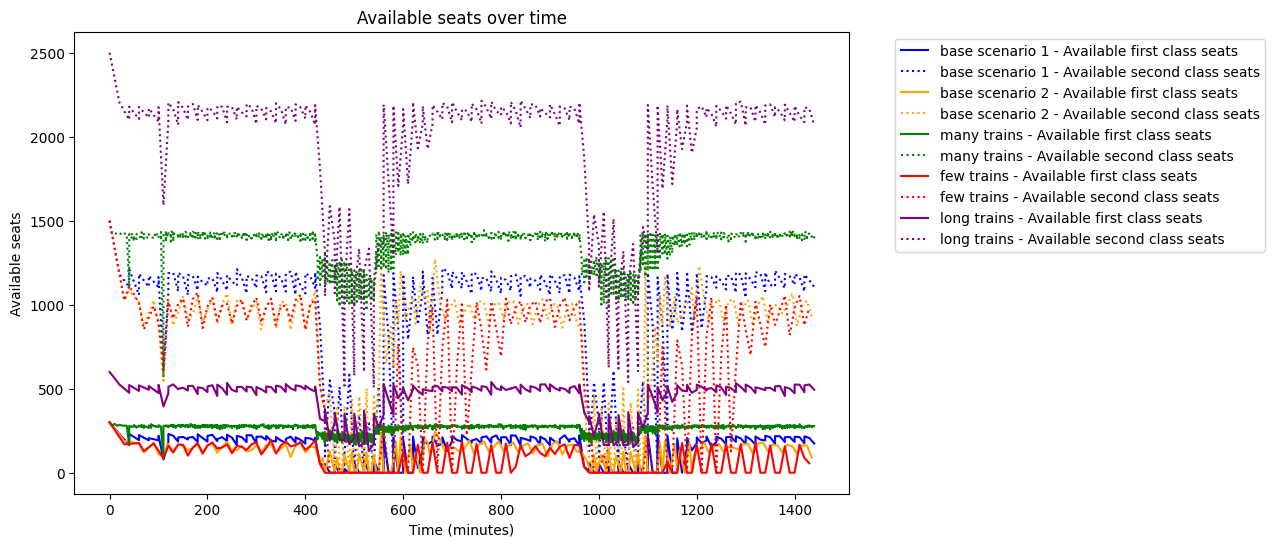

In [37]:
plt.figure(figsize=(10, 6))
colors = ["blue", "orange", "green", "red", "purple"]
for i, (scenario_name, scenario) in enumerate(scenarios.items()):
    plt.plot(
        scenario["result"].times_available_first,
        scenario["result"].list_available_first,
        label=f"{scenario_name} - Available first class seats",
        color=colors[i],
        markersize=3,
    )
    plt.plot(
        scenario["result"].times_available_second,
        scenario["result"].list_available_second,
        label=f"{scenario_name} - Available second class seats",
        color=colors[i],
        linestyle="dotted",
        markersize=3,
    )

plt.xlabel("Time (minutes)")
plt.ylabel("Available seats")
plt.title("Available seats over time")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

In [38]:
# Number of independent simulations
D = 1

print(f"Running {D} independent simulations for Scenario 1 (20-min frequency)...")
times_queues_scenario1 = []

for d in range(D):
    simulation_result = simulate(scenario1)
    times_queues_scenario1.append(
        (simulation_result.time_history, simulation_result.queue_history)
    )
    print(f"Simulation {d + 1}/{D} completed.")

times_queues_scenario2 = []

for d in range(D):
    simulation_result = simulate(scenario2)
    times_queues_scenario2.append(
        (simulation_result.time_history, simulation_result.queue_history)
    )
    print(f"Simulation {d + 1}/{D} completed.")

print("\nAll simulations done!")

Running 1 independent simulations for Scenario 1 (20-min frequency)...


NameError: name 'scenario1' is not defined

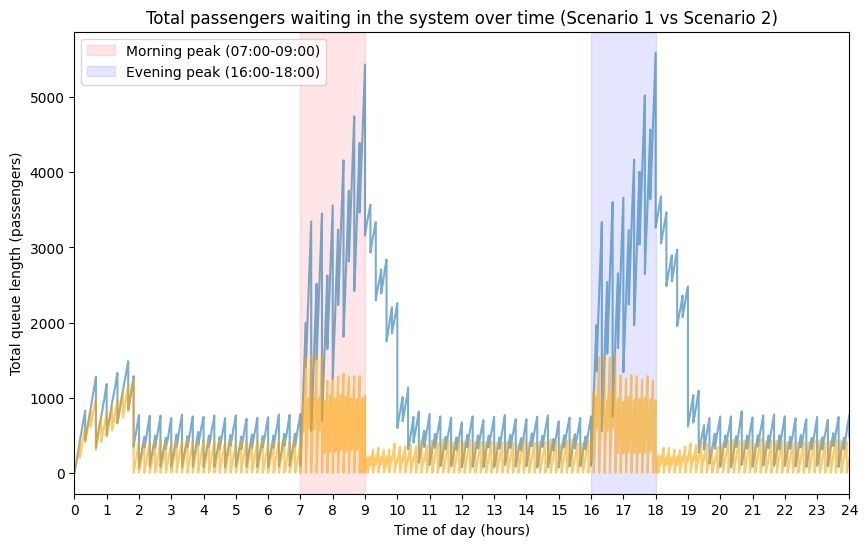

In [ ]:
fig = plt.figure(figsize=(10, 6))
ax = plt.subplot(1, 1, 1)

# Plot each simulation run
for t, q in times_queues_scenario1:
    # Convert time from minutes to hours
    t_hours = [time / 60 for time in t]
    ax.plot(t_hours, q, alpha=0.6)

for t, q in times_queues_scenario2:
    # Convert time from minutes to hours
    t_hours = [time / 60 for time in t]
    ax.plot(t_hours, q, alpha=0.6, color="orange")

# Formatting the plot
ax.set(
    title="Total passengers waiting in the system over time (Scenario 1 vs Scenario 2)",
    xlabel="Time of day (hours)",
    ylabel="Total queue length (passengers)",
)

# Add vertical lines to show the peak periods (now in hours!)
ax.axvspan(7, 9, color="red", alpha=0.1, label="Morning peak (07:00-09:00)")
ax.axvspan(16, 18, color="blue", alpha=0.1, label="Evening peak (16:00-18:00)")

# Set x-axis limits and ticks to show hours clearly (from 0 to 24, every 2 hours)
ax.set_xlim(0, 24)
ax.set_xticks(range(0, 25, 1))

ax.legend()

plt.show()

NameError: name 'empty_seats_first' is not defined

<Figure size 1000x600 with 0 Axes>